# Wide Receiver Next-Season Projection Model

This notebook builds a machine learning model to predict a wide receiver's **next-season fantasy points per game** using prior-season production, usage, and career-context features.

The project is designed to demonstrate:

- Sports analytics modeling
- Time-aware train/test splitting
- Feature engineering
- Model comparison
- Player-level projections
- Feature importance / model interpretation

This version intentionally avoids TensorFlow and uses reliable scikit-learn models instead.

In [9]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn xgboost

  Using cached pandas-2.3.3-cp310-cp310-macosx_10_9_x86_64.whl.metadata (91 kB)
  Using cached matplotlib-3.10.9-cp310-cp310-macosx_10_12_x86_64.whl.metadata (52 kB)
  Using cached xgboost-3.2.0-py3-none-macosx_10_15_x86_64.whl.metadata (2.1 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.2-cp310-cp310-macosx_10_9_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp310-cp310-macosx_10_9_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-macosx_10_9_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp310-cp310-macosx_10_10_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-2.3.3-cp310-cp310-macosx_10_9_x86_64.whl (11.6 MB)
Using cached matplotlib-3.10.9-cp310-cp310-macosx_10_12_x86_64.whl (8.3 MB)
Using c

In [11]:
# Core packages
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

RANDOM_STATE = 42

## 1. Load the data

Update `DATA_PATH` if your file moves. The path below matches the file path you provided.

In [12]:
DATA_PATH = "/Users/benzurlo/Downloads/Historical Wr Data - players (2).csv"

# Fallback path for this ChatGPT-created version. You can ignore this locally.
if not os.path.exists(DATA_PATH):
    fallback_path = "/mnt/data/Historical Wr Data - players (2)(1).csv"
    if os.path.exists(fallback_path):
        DATA_PATH = fallback_path

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df.shape}")
df.head()

Loaded: /Users/benzurlo/Downloads/Historical Wr Data - players (2).csv
Shape: (1100, 22)


,Season,Draft Year,Year in League,Player,Player Clean Name,TGT,REC,YDS,TD,ATT,YDS.1,TD.1,G,FPTS/G,Opportunities/G,Rec/G,Total Yds/G,Next Year FPTS/G,Next Year Opportunities/G,Next Year Rec/G,Next Year Total Yds/G,Change in PTS/G
0,2025,2023,3,Puka Nacua (LAR),Puka Nacua,166,129,"1,715",10,10,105,1,16,23.4,11.0,8.1,113.8,NaN,NaN,NaN,NaN,-23.4
1,2025,2023,3,Jaxon Smith-Njigba (SEA),Jaxon Smith-Njigba,163,119,"1,793",10,7,36,0,17,21.2,10.0,7.0,107.6,NaN,NaN,NaN,NaN,-21.2
2,2025,2021,5,Amon-Ra St. Brown (DET),Amon-Ra St. Brown,172,117,"1,401",11,3,9,0,17,19.1,10.3,6.9,82.9,NaN,NaN,NaN,NaN,-19.1
3,2025,2021,5,Ja'Marr Chase (CIN),Ja'Marr Chase,185,125,"1,412",8,3,14,0,16,19.6,11.8,7.8,89.1,NaN,NaN,NaN,NaN,-19.6
4,2025,2022,4,George Pickens (DAL),George Pickens,137,93,"1,429",9,0,0,0,17,17.2,8.1,5.5,84.1,NaN,NaN,NaN,NaN,-17.2


## 2. Initial data checks

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Season                     1100 non-null   int64  
 1   Draft Year                 1100 non-null   int64  
 2   Year in League             1100 non-null   int64  
 3   Player                     1100 non-null   object 
 4   Player Clean Name          1100 non-null   object 
 5   TGT                        1100 non-null   int64  
 6   REC                        1100 non-null   int64  
 7   YDS                        1100 non-null   object 
 8   TD                         1100 non-null   int64  
 9   ATT                        1100 non-null   int64  
 10  YDS.1                      1100 non-null   int64  
 11  TD.1                       1100 non-null   int64  
 12  G                          1100 non-null   int64  
 13  FPTS/G                     1100 non-null   float

In [14]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Season,1100.0,NaN,NaN,NaN,2020.0,3.163716,2015.0,2017.0,2020.0,2023.0,2025.0
Draft Year,1100.0,NaN,NaN,NaN,2016.298182,4.361111,2003.0,2014.0,2016.0,2019.0,2025.0
Year in League,1100.0,NaN,NaN,NaN,4.701818,2.947863,1.0,2.0,4.0,6.0,17.0
Player,1100,348,Stefon Diggs (FA),11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Player Clean Name,1100,348,Stefon Diggs,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TGT,1100.0,NaN,NaN,NaN,85.864545,36.073992,18.0,56.0,80.0,108.25,203.0
REC,1100.0,NaN,NaN,NaN,54.165455,24.858981,12.0,34.0,49.0,69.25,149.0
YDS,1100,695,394,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TD,1100.0,NaN,NaN,NaN,4.42,2.896762,0.0,2.0,4.0,6.0,18.0
ATT,1100.0,NaN,NaN,NaN,2.680909,5.01617,0.0,0.0,1.0,3.0,59.0


## 3. Clean numeric columns

Some yardage columns may contain commas, such as `1,715`, so this step converts all numeric-looking columns into usable numeric fields.

In [15]:
df_clean = df.copy()

# Strip whitespace from column names
df_clean.columns = [c.strip() for c in df_clean.columns]

# Convert numeric columns safely
for col in df_clean.columns:
    if col not in ["Player", "Player Clean Name"]:
        df_clean[col] = (
            df_clean[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.replace("%", "", regex=False)
            .replace({"nan": np.nan, "None": np.nan, "": np.nan})
        )
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

print(df_clean.dtypes)
df_clean.head()

Season                         int64
Draft Year                     int64
Year in League                 int64
Player                        object
Player Clean Name             object
TGT                            int64
REC                            int64
YDS                            int64
TD                             int64
ATT                            int64
YDS.1                          int64
TD.1                           int64
G                              int64
FPTS/G                       float64
Opportunities/G              float64
Rec/G                        float64
Total Yds/G                  float64
Next Year FPTS/G             float64
Next Year Opportunities/G    float64
Next Year Rec/G              float64
Next Year Total Yds/G        float64
Change in PTS/G              float64
dtype: object


,Season,Draft Year,Year in League,Player,Player Clean Name,TGT,REC,YDS,TD,ATT,YDS.1,TD.1,G,FPTS/G,Opportunities/G,Rec/G,Total Yds/G,Next Year FPTS/G,Next Year Opportunities/G,Next Year Rec/G,Next Year Total Yds/G,Change in PTS/G
0,2025,2023,3,Puka Nacua (LAR),Puka Nacua,166,129,1715,10,10,105,1,16,23.4,11.0,8.1,113.8,NaN,NaN,NaN,NaN,-23.4
1,2025,2023,3,Jaxon Smith-Njigba (SEA),Jaxon Smith-Njigba,163,119,1793,10,7,36,0,17,21.2,10.0,7.0,107.6,NaN,NaN,NaN,NaN,-21.2
2,2025,2021,5,Amon-Ra St. Brown (DET),Amon-Ra St. Brown,172,117,1401,11,3,9,0,17,19.1,10.3,6.9,82.9,NaN,NaN,NaN,NaN,-19.1
3,2025,2021,5,Ja'Marr Chase (CIN),Ja'Marr Chase,185,125,1412,8,3,14,0,16,19.6,11.8,7.8,89.1,NaN,NaN,NaN,NaN,-19.6
4,2025,2022,4,George Pickens (DAL),George Pickens,137,93,1429,9,0,0,0,17,17.2,8.1,5.5,84.1,NaN,NaN,NaN,NaN,-17.2


## 4. Feature engineering

The base data already includes useful per-game metrics. We add several football-specific features:

- Catch rate
- Yards per target
- Yards per reception
- Receiving TD rate
- Total TDs
- Total touches/opportunities
- Availability-adjusted volume

These features help separate volume, efficiency, scoring, and durability.

In [16]:
df_feat = df_clean.copy()

# Avoid division-by-zero issues
def safe_divide(numerator, denominator):
    return np.where(denominator > 0, numerator / denominator, 0)

df_feat["Catch Rate"] = safe_divide(df_feat["REC"], df_feat["TGT"])
df_feat["Yards Per Target"] = safe_divide(df_feat["YDS"], df_feat["TGT"])
df_feat["Yards Per Reception"] = safe_divide(df_feat["YDS"], df_feat["REC"])
df_feat["Receiving TD Rate"] = safe_divide(df_feat["TD"], df_feat["TGT"])
df_feat["Rush Yards Per Attempt"] = safe_divide(df_feat["YDS.1"], df_feat["ATT"])
df_feat["Total TD"] = df_feat["TD"] + df_feat["TD.1"]
df_feat["Total Opportunities"] = df_feat["TGT"] + df_feat["ATT"]
df_feat["Total Yards"] = df_feat["YDS"] + df_feat["YDS.1"]
df_feat["Targets Per Game"] = safe_divide(df_feat["TGT"], df_feat["G"])
df_feat["Fantasy Points Per Opportunity"] = safe_divide(df_feat["FPTS/G"], df_feat["Opportunities/G"])

df_feat.replace([np.inf, -np.inf], np.nan, inplace=True)
df_feat.head()

,Season,Draft Year,Year in League,Player,Player Clean Name,TGT,REC,YDS,TD,ATT,YDS.1,TD.1,G,FPTS/G,Opportunities/G,Rec/G,Total Yds/G,Next Year FPTS/G,Next Year Opportunities/G,Next Year Rec/G,Next Year Total Yds/G,Change in PTS/G,Catch Rate,Yards Per Target,Yards Per Reception,Receiving TD Rate,Rush Yards Per Attempt,Total TD,Total Opportunities,Total Yards,Targets Per Game,Fantasy Points Per Opportunity
0,2025,2023,3,Puka Nacua (LAR),Puka Nacua,166,129,1715,10,10,105,1,16,23.4,11.0,8.1,113.8,NaN,NaN,NaN,NaN,-23.4,0.777108,10.331325,13.294574,0.060241,10.500000,11,176,1820,10.375000,2.127273
1,2025,2023,3,Jaxon Smith-Njigba (SEA),Jaxon Smith-Njigba,163,119,1793,10,7,36,0,17,21.2,10.0,7.0,107.6,NaN,NaN,NaN,NaN,-21.2,0.730061,11.000000,15.067227,0.061350,5.142857,10,170,1829,9.588235,2.120000
2,2025,2021,5,Amon-Ra St. Brown (DET),Amon-Ra St. Brown,172,117,1401,11,3,9,0,17,19.1,10.3,6.9,82.9,NaN,NaN,NaN,NaN,-19.1,0.680233,8.145349,11.974359,0.063953,3.000000,11,175,1410,10.117647,1.854369
3,2025,2021,5,Ja'Marr Chase (CIN),Ja'Marr Chase,185,125,1412,8,3,14,0,16,19.6,11.8,7.8,89.1,NaN,NaN,NaN,NaN,-19.6,0.675676,7.632432,11.296000,0.043243,4.666667,8,188,1426,11.562500,1.661017
4,2025,2022,4,George Pickens (DAL),George Pickens,137,93,1429,9,0,0,0,17,17.2,8.1,5.5,84.1,NaN,NaN,NaN,NaN,-17.2,0.678832,10.430657,15.365591,0.065693,0.000000,9,137,1429,8.058824,2.123457


## 5. Define modeling target and features

Target: `Next Year FPTS/G`

This predicts how many fantasy points per game a WR scores in the following season.

In [17]:
target_col = "Next Year FPTS/G"

base_feature_cols = [
    "Season",
    "Draft Year",
    "Year in League",
    "TGT",
    "REC",
    "YDS",
    "TD",
    "ATT",
    "YDS.1",
    "TD.1",
    "G",
    "FPTS/G",
    "Opportunities/G",
    "Rec/G",
    "Total Yds/G",
    "Catch Rate",
    "Yards Per Target",
    "Yards Per Reception",
    "Receiving TD Rate",
    "Rush Yards Per Attempt",
    "Total TD",
    "Total Opportunities",
    "Total Yards",
    "Targets Per Game",
    "Fantasy Points Per Opportunity",
]

# Keep only columns that actually exist in the data
feature_cols = [col for col in base_feature_cols if col in df_feat.columns]
missing_features = [col for col in base_feature_cols if col not in df_feat.columns]

print("Feature columns used:")
print(feature_cols)

if missing_features:
    print("Missing optional features:")
    print(missing_features)

# Remove rows without next-year target, which should mostly remove the most recent season
df_model = df_feat.dropna(subset=[target_col]).copy()

print(f"Modeling rows: {df_model.shape[0]}")
print(f"Seasons available for modeling: {sorted(df_model['Season'].dropna().unique())}")

Feature columns used:
['Season', 'Draft Year', 'Year in League', 'TGT', 'REC', 'YDS', 'TD', 'ATT', 'YDS.1', 'TD.1', 'G', 'FPTS/G', 'Opportunities/G', 'Rec/G', 'Total Yds/G', 'Catch Rate', 'Yards Per Target', 'Yards Per Reception', 'Receiving TD Rate', 'Rush Yards Per Attempt', 'Total TD', 'Total Opportunities', 'Total Yards', 'Targets Per Game', 'Fantasy Points Per Opportunity']
Modeling rows: 695
Seasons available for modeling: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


## 6. Leakage-safe time split

We split by season rather than randomly. This better reflects a real projection problem.

- Train: 2015–2022
- Validation: 2023
- Test: 2024

If the data changes later, the split logic below will still work as long as those seasons exist.

In [18]:
train_seasons = list(range(2015, 2023))
valid_season = 2023
test_season = 2024

train_df = df_model[df_model["Season"].isin(train_seasons)].copy()
valid_df = df_model[df_model["Season"] == valid_season].copy()
test_df = df_model[df_model["Season"] == test_season].copy()

# If validation/test seasons are unavailable, use a dynamic fallback based on latest seasons
if len(valid_df) == 0 or len(test_df) == 0:
    available_seasons = sorted(df_model["Season"].dropna().unique())
    test_season = available_seasons[-1]
    valid_season = available_seasons[-2]
    train_seasons = available_seasons[:-2]
    train_df = df_model[df_model["Season"].isin(train_seasons)].copy()
    valid_df = df_model[df_model["Season"] == valid_season].copy()
    test_df = df_model[df_model["Season"] == test_season].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_valid = valid_df[feature_cols]
y_valid = valid_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f"Train seasons: {min(train_seasons)}-{max(train_seasons)} | Rows: {len(train_df)}")
print(f"Validation season: {valid_season} | Rows: {len(valid_df)}")
print(f"Test season: {test_season} | Rows: {len(test_df)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_valid shape: {X_valid.shape}")
print(f"X_test shape: {X_test.shape}")

Train seasons: 2015-2022 | Rows: 549
Validation season: 2023 | Rows: 71
Test season: 2024 | Rows: 75
X_train shape: (549, 25)
X_valid shape: (71, 25)
X_test shape: (75, 25)


## 7. Baseline model

A strong project should compare machine learning models against a simple baseline. Here the baseline prediction is simply the player's current-season fantasy points per game.

In [20]:
def regression_metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"RMSE": rmse, "MAE": mae, "R2": r2}

baseline_valid_pred = valid_df["FPTS/G"]
baseline_test_pred = test_df["FPTS/G"]

results = []
results.append({"Model": "Baseline: Current FPTS/G", "Split": "Validation", **regression_metrics(y_valid, baseline_valid_pred)})
results.append({"Model": "Baseline: Current FPTS/G", "Split": "Test", **regression_metrics(y_test, baseline_test_pred)})

pd.DataFrame(results)

,Model,Split,RMSE,MAE,R2
0,Baseline: Current FPTS/G,Validation,4.166043,3.426761,-0.011571
1,Baseline: Current FPTS/G,Test,3.737076,2.972000,0.237869


## 8. Train machine learning models

In [21]:

models = {
    "Linear Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=500,
            max_depth=6,
            min_samples_leaf=5,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=3,
            random_state=RANDOM_STATE
        ))
    ])
}

# Optional XGBoost if installed
try:
    from xgboost import XGBRegressor
    models["XGBoost"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBRegressor(
            n_estimators=400,
            learning_rate=0.03,
            max_depth=3,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="reg:squarederror",
            random_state=RANDOM_STATE
        ))
    ])
    print("XGBoost found and added.")
except Exception as e:
    print("XGBoost not installed. Skipping XGBoost.")
    print("To add it later, run: pip install xgboost")

model_results = []
fitted_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[model_name] = model
    
    valid_pred = model.predict(X_valid)
    test_pred = model.predict(X_test)
    
    model_results.append({"Model": model_name, "Split": "Validation", **regression_metrics(y_valid, valid_pred)})
    model_results.append({"Model": model_name, "Split": "Test", **regression_metrics(y_test, test_pred)})

all_results = pd.concat([
    pd.DataFrame(results),
    pd.DataFrame(model_results)
], ignore_index=True)

all_results.sort_values(["Split", "RMSE"])

XGBoost not installed. Skipping XGBoost.
To add it later, run: pip install xgboost


,Model,Split,RMSE,MAE,R2
3,Linear Regression,Test,3.139152,2.546800,0.462237
5,Ridge Regression,Test,3.153996,2.565295,0.457139
7,Random Forest,Test,3.356896,2.705134,0.385047
9,Gradient Boosting,Test,3.593130,2.933059,0.295450
1,Baseline: Current FPTS/G,Test,3.737076,2.972000,0.237869
6,Random Forest,Validation,3.476137,2.848179,0.295725
4,Ridge Regression,Validation,3.486264,2.972149,0.291615
2,Linear Regression,Validation,3.502435,2.988200,0.285028
8,Gradient Boosting,Validation,3.672839,3.039077,0.213765
0,Baseline: Current FPTS/G,Validation,4.166043,3.426761,-0.011571


## 9. Visualize model comparison

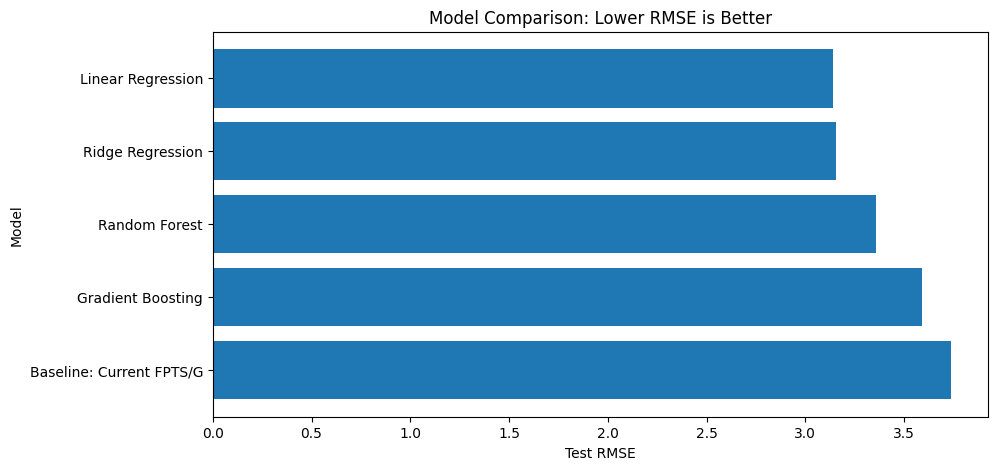

,Model,Split,RMSE,MAE,R2
3,Linear Regression,Test,3.139152,2.546800,0.462237
5,Ridge Regression,Test,3.153996,2.565295,0.457139
7,Random Forest,Test,3.356896,2.705134,0.385047
9,Gradient Boosting,Test,3.593130,2.933059,0.295450
1,Baseline: Current FPTS/G,Test,3.737076,2.972000,0.237869


In [22]:
test_results = all_results[all_results["Split"] == "Test"].sort_values("RMSE")

plt.figure(figsize=(10, 5))
plt.barh(test_results["Model"], test_results["RMSE"])
plt.xlabel("Test RMSE")
plt.ylabel("Model")
plt.title("Model Comparison: Lower RMSE is Better")
plt.gca().invert_yaxis()
plt.show()

test_results

## 10. Select best model

We select the model with the lowest validation RMSE, then evaluate its predictions on the test season.

In [23]:
valid_results = all_results[all_results["Split"] == "Validation"].copy()
best_model_name = valid_results.sort_values("RMSE").iloc[0]["Model"]

print(f"Best validation model: {best_model_name}")

if best_model_name == "Baseline: Current FPTS/G":
    test_predictions = baseline_test_pred.values
    best_model = None
else:
    best_model = fitted_models[best_model_name]
    test_predictions = best_model.predict(X_test)

final_metrics = regression_metrics(y_test, test_predictions)
print("Test metrics:")
final_metrics

Best validation model: Random Forest
Test metrics:


{'RMSE': 3.3568955770737534,
 'MAE': 2.705134014198634,
 'R2': 0.3850473959736268}

## 11. Player-level test predictions

In [24]:
prediction_df = test_df[["Season", "Player", "Player Clean Name", "FPTS/G", target_col]].copy()
prediction_df["Predicted Next Year FPTS/G"] = test_predictions
prediction_df["Prediction Error"] = prediction_df["Predicted Next Year FPTS/G"] - prediction_df[target_col]
prediction_df["Absolute Error"] = prediction_df["Prediction Error"].abs()

prediction_df.sort_values("Predicted Next Year FPTS/G", ascending=False).head(25)

,Season,Player,Player Clean Name,FPTS/G,Next Year FPTS/G,Predicted Next Year FPTS/G,Prediction Error,Absolute Error
100,2024,Ja'Marr Chase (CIN),Ja'Marr Chase,23.7,19.6,19.977864,0.377864,0.377864
101,2024,Justin Jefferson (MIN),Justin Jefferson,18.7,11.9,17.817576,5.917576,5.917576
102,2024,Amon-Ra St. Brown (DET),Amon-Ra St. Brown,18.6,19.1,16.839289,-2.260711,2.260711
103,2024,Brian Thomas (JAC),Brian Thomas,16.7,9.9,16.657297,6.757297,6.757297
107,2024,CeeDee Lamb (DAL),CeeDee Lamb,17.6,14.4,16.570507,2.170507,2.170507
152,2024,Chris Godwin (TB),Chris Godwin,19.7,9.2,16.416895,7.216895,7.216895
125,2024,Puka Nacua (LAR),Puka Nacua,18.8,23.4,16.365438,-7.034562,7.034562
116,2024,Tee Higgins (CIN),Tee Higgins,18.5,14.1,16.088034,1.988034,1.988034
104,2024,Drake London (ATL),Drake London,16.5,16.8,15.432411,-1.367589,1.367589
122,2024,Nico Collins (HOU),Nico Collins,17.6,15.1,15.401618,0.301618,0.301618


## 12. Biggest misses

These cases are useful for model evaluation because they reveal players whose next-season performance was difficult to predict from prior-year data alone.

In [25]:
prediction_df.sort_values("Absolute Error", ascending=False).head(20)

,Season,Player,Player Clean Name,FPTS/G,Next Year FPTS/G,Predicted Next Year FPTS/G,Prediction Error,Absolute Error
193,2024,Chris Olave (NO),Chris Olave,9.6,16.8,9.507500,-7.292500,7.292500
152,2024,Chris Godwin (TB),Chris Godwin,19.7,9.2,16.416895,7.216895,7.216895
112,2024,Jerry Jeudy (CLE),Jerry Jeudy,14.2,7.1,14.216027,7.116027,7.116027
125,2024,Puka Nacua (LAR),Puka Nacua,18.8,23.4,16.365438,-7.034562,7.034562
108,2024,Jaxon Smith-Njigba (SEA),Jaxon Smith-Njigba,14.9,21.2,14.436367,-6.763633,6.763633
103,2024,Brian Thomas (JAC),Brian Thomas,16.7,9.9,16.657297,6.757297,6.757297
137,2024,Cooper Kupp (SEA),Cooper Kupp,14.6,7.3,13.779833,6.479833,6.479833
101,2024,Justin Jefferson (MIN),Justin Jefferson,18.7,11.9,17.817576,5.917576,5.917576
141,2024,George Pickens (DAL),George Pickens,11.7,17.2,11.547177,-5.652823,5.652823
130,2024,Darnell Mooney (NYG),Darnell Mooney,12.1,5.5,11.058927,5.558927,5.558927


## 13. Actual vs. predicted plot

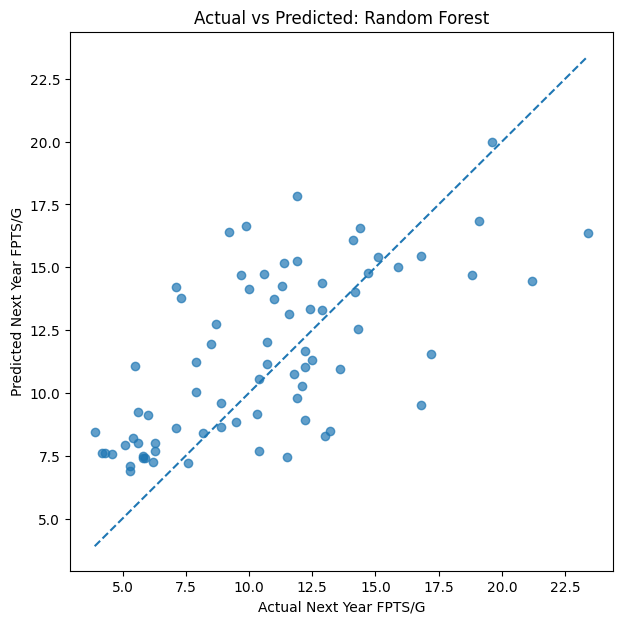

In [26]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, test_predictions, alpha=0.7)
min_val = min(y_test.min(), test_predictions.min())
max_val = max(y_test.max(), test_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual Next Year FPTS/G")
plt.ylabel("Predicted Next Year FPTS/G")
plt.title(f"Actual vs Predicted: {best_model_name}")
plt.show()

## 14. Feature importance

For the selected model, we use permutation importance on the test set. This measures how much model performance worsens when each feature is randomly shuffled.

,Feature,Importance,Std
11,FPTS/G,3.576135e-01,1.547125e-01
14,Total Yds/G,2.682209e-01,1.491624e-01
23,Targets Per Game,6.289890e-02,3.515813e-02
15,Catch Rate,2.866202e-02,1.652999e-02
12,Opportunities/G,2.338178e-02,2.296640e-02
8,YDS.1,1.788652e-02,9.115428e-03
2,Year in League,1.341645e-02,2.369260e-02
3,TGT,6.860957e-03,7.903492e-03
16,Yards Per Target,4.279943e-03,1.009675e-02
1,Draft Year,3.873214e-03,6.193279e-03


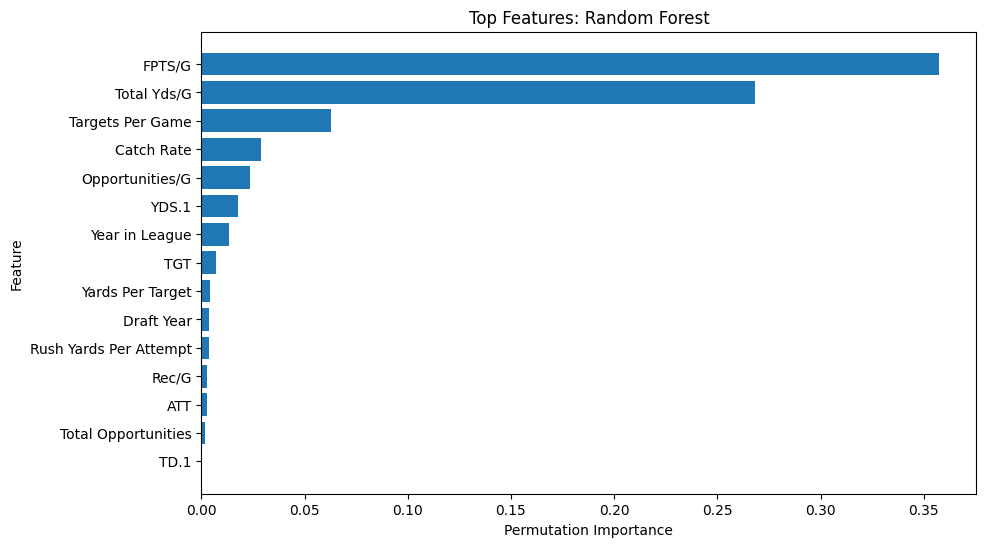

In [27]:
if best_model is not None:
    perm = permutation_importance(
        best_model,
        X_test,
        y_test,
        n_repeats=20,
        random_state=RANDOM_STATE,
        scoring="neg_root_mean_squared_error"
    )

    importance_df = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": perm.importances_mean,
        "Std": perm.importances_std
    }).sort_values("Importance", ascending=False)

    display(importance_df.head(20))

    top_importance = importance_df.head(15).sort_values("Importance")
    plt.figure(figsize=(10, 6))
    plt.barh(top_importance["Feature"], top_importance["Importance"])
    plt.xlabel("Permutation Importance")
    plt.ylabel("Feature")
    plt.title(f"Top Features: {best_model_name}")
    plt.show()
else:
    print("Baseline model selected, so there is no ML feature importance to show.")

## 15. Train final model on all historical rows with known next-year outcomes

After evaluating the model, we can train a final version using all seasons where we know the next-year result. Then we use it to project the most recent season's players.

In [28]:
# Choose the best non-baseline model for final projection
non_baseline_valid = valid_results[valid_results["Model"] != "Baseline: Current FPTS/G"].copy()
final_model_name = non_baseline_valid.sort_values("RMSE").iloc[0]["Model"]
print(f"Final projection model: {final_model_name}")

final_model = models[final_model_name]

X_all_known = df_model[feature_cols]
y_all_known = df_model[target_col]
final_model.fit(X_all_known, y_all_known)

latest_season = int(df_feat["Season"].max())
latest_df = df_feat[df_feat["Season"] == latest_season].copy()
X_latest = latest_df[feature_cols]

latest_df["Projected Next Year FPTS/G"] = final_model.predict(X_latest)
latest_df["Projected Change"] = latest_df["Projected Next Year FPTS/G"] - latest_df["FPTS/G"]

projection_cols = [
    "Season", "Player", "Player Clean Name", "Year in League", "G", "TGT", "REC", "YDS", "TD",
    "FPTS/G", "Projected Next Year FPTS/G", "Projected Change"
]

latest_projections = latest_df[projection_cols].sort_values("Projected Next Year FPTS/G", ascending=False)
latest_projections.head(30)

Final projection model: Random Forest


,Season,Player,Player Clean Name,Year in League,G,TGT,REC,YDS,TD,FPTS/G,Projected Next Year FPTS/G,Projected Change
1,2025,Jaxon Smith-Njigba (SEA),Jaxon Smith-Njigba,3,17,163,119,1793,10,21.2,19.289736,-1.910264
0,2025,Puka Nacua (LAR),Puka Nacua,3,16,166,129,1715,10,23.4,19.000620,-4.399380
2,2025,Amon-Ra St. Brown (DET),Amon-Ra St. Brown,5,17,172,117,1401,11,19.1,17.416845,-1.683155
3,2025,Ja'Marr Chase (CIN),Ja'Marr Chase,5,16,185,125,1412,8,19.6,16.872207,-2.727793
5,2025,Chris Olave (NO),Chris Olave,4,16,156,100,1163,9,16.8,16.360542,-0.439458
39,2025,Rashee Rice (KC),Rashee Rice,3,8,78,53,571,5,18.8,15.872176,-2.927824
4,2025,George Pickens (DAL),George Pickens,4,17,137,93,1429,9,17.2,15.610709,-1.589291
18,2025,Drake London (ATL),Drake London,4,12,112,68,919,7,16.8,15.185761,-1.614239
6,2025,Zay Flowers (BAL),Zay Flowers,3,17,118,86,1211,5,14.3,14.104769,-0.195231
7,2025,Nico Collins (HOU),Nico Collins,5,15,120,71,1117,6,15.1,12.974211,-2.125789


## 16. Positive regression candidates

This table highlights players who had strong usage/volume but whose projected next-year fantasy points per game are meaningfully higher than their current-year fantasy points per game.

In [29]:
positive_regression = latest_projections[
    (latest_projections["Projected Change"] > 1.0) &
    (latest_projections["TGT"] >= latest_projections["TGT"].quantile(0.50))
].copy()

positive_regression.sort_values("Projected Change", ascending=False).head(25)

,Season,Player,Player Clean Name,Year in League,G,TGT,REC,YDS,TD,FPTS/G,Projected Next Year FPTS/G,Projected Change
72,2025,Adonai Mitchell (NYJ),Adonai Mitchell,2,16,74,33,453,2,5.5,9.350346,3.850346
58,2025,Xavier Worthy (KC),Xavier Worthy,2,14,73,42,532,1,7.9,10.621757,2.721757
51,2025,Jerry Jeudy (CLE),Jerry Jeudy,6,17,106,50,602,2,7.1,9.441724,2.341724
38,2025,Rashid Shaheed (SEA),Rashid Shaheed,4,18,92,59,687,2,8.7,10.577308,1.877308
54,2025,Elic Ayomanor (TEN),Elic Ayomanor,1,16,89,41,515,4,7.3,9.012440,1.712440
37,2025,Tre Tucker (LV),Tre Tucker,3,17,92,57,696,5,9.5,10.844358,1.344358
41,2025,Brian Thomas (JAC),Brian Thomas,2,14,91,48,707,2,9.9,11.244027,1.344027


## 17. Export projections

This saves the latest-season player projections as a CSV.

In [ ]:
output_path = "wr_next_season_projections.csv"
latest_projections.to_csv(output_path, index=False)
print(f"Saved projections to: {output_path}")

## 18. Portfolio summary

This project uses historical wide receiver production and usage data to predict next-season fantasy points per game. The workflow emphasizes a realistic forecasting setup by splitting data chronologically rather than randomly, preventing future information from leaking into training.

Key modeling steps included feature engineering, baseline comparison, multiple regression algorithms, validation-based model selection, player-level error analysis, and feature importance. This structure mirrors the type of applied sports analytics workflow used in player evaluation and projection systems.